# MNIST Demonstration with TensorFlow on GPU

## Import TensorFlow and Test GPU in Jupyter

In [1]:
import tensorflow as tf

In [2]:
print("TensorFlow version:", tf.__version__)

print(f"Is TensorFlow built with CUDA support? {'Yes' if tf.test.is_built_with_cuda() else 'No'}")

if tf.config.list_physical_devices('GPU'):
    print("GPU devices found:")
    for gpu in tf.config.list_physical_devices('GPU'):
        print(f"  - {gpu}")
else:    
    print("No GPU devices found.")


TensorFlow version: 2.21.0
Is TensorFlow built with CUDA support? Yes
GPU devices found:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## Other imports and Load MNIST Dataset

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [5]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [6]:
x_test.shape, y_test.shape

((10000, 28, 28), (10000,))

### Normalize the Data:

In [7]:
x_train.min(), x_train.max()

(np.uint8(0), np.uint8(255))

In [8]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [9]:
x_train.min(), x_train.max()

(np.float64(0.0), np.float64(1.0))

### Change y_train & y_test to Categorical:

In [10]:
y_train[0]

np.uint8(5)

In [11]:
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [12]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

### Visualize the Data:

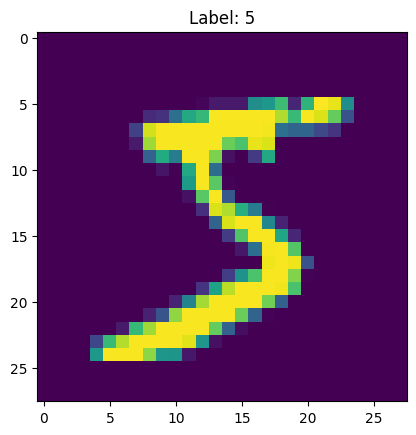

In [13]:
plt.imshow(x_train[0])
plt.title(f"Label: {np.argmax(y_train[0])}")
plt.show()

In [14]:
idx = [-1] * 10

for i in range(10):
    if(idx[i] == -1):
        for j in range(y_train.shape[0]):
            if(np.argmax(y_train[j]) == i):
                idx[i] = j
                break
idx

[1, 3, 5, 7, 2, 0, 13, 15, 17, 4]

In [15]:
totals = [0] * 10

for i in range(y_train.shape[0]):
    totals[np.argmax(y_train[i])] += 1

totals

[5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]

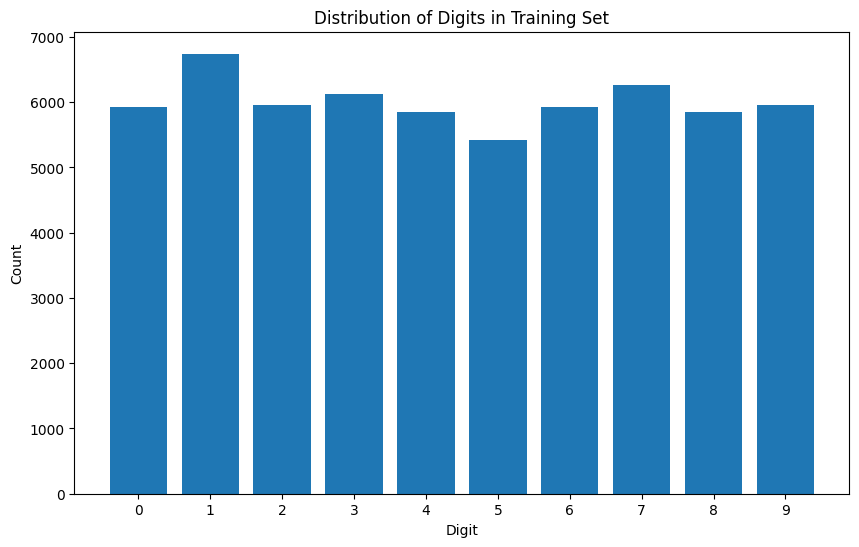

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(range(10), totals)
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Distribution of Digits in Training Set')
plt.xticks(range(10))
plt.show()

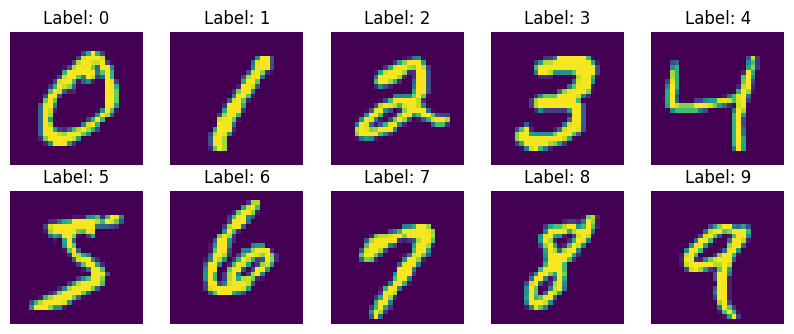

In [17]:
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[idx[i]])
    plt.title(f"Label: {np.argmax(y_train[idx[i]])}")
    plt.axis('off')
plt.show()

## Define & Train the Model:

In [18]:
model = tf.keras.models.Sequential()

model.add(tf.keras.Input(shape=(28, 28,)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(512, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer = 'adam', 
    loss= 'categorical_crossentropy', 
    metrics= ['accuracy']
)

In [21]:
history = model.fit(x_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 597us/step - accuracy: 0.9407 - loss: 0.2022
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 578us/step - accuracy: 0.9754 - loss: 0.0793
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 581us/step - accuracy: 0.9838 - loss: 0.0513
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 595us/step - accuracy: 0.9886 - loss: 0.0366
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 575us/step - accuracy: 0.9913 - loss: 0.0265


## Test Model:

In [22]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9802 - loss: 0.0765


[0.07645677775144577, 0.9801999926567078]

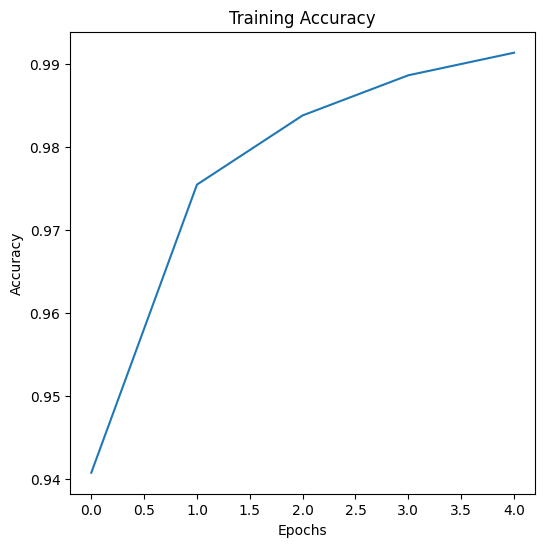

In [23]:
plt.figure(figsize=(6, 6))
plt.title("Training Accuracy")
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [24]:
print(classification_report(np.argmax(y_test, axis=1), np.argmax(model.predict(x_test), axis=1)))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.99      0.97      0.98      1010
           4       0.97      0.99      0.98       982
           5       0.96      0.99      0.97       892
           6       0.99      0.98      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.99      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step


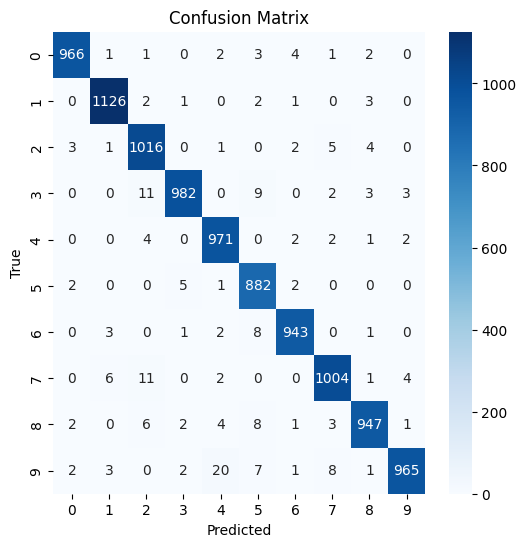

In [25]:
cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(model.predict(x_test), axis=1))

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()